# 03 - Feature Engineering
Membangun fitur-fitur yang akan digunakan oleh model machine learning (Lag, Rolling Stats, Seasonal Flags).

In [14]:
import pandas as pd
import numpy as np
import os
import sys

# Add src to path
sys.path.append('../')

Feature Engineering Complete.
Total features created: 17


,date,pcpipch,inflation_yoy,lag_1_inflation,lag_2_inflation,lag_3_inflation,lag_6_inflation,lag_12_inflation,roll3_inflation_mean,roll6_inflation_mean,roll3_inflation_std,month_sin,month_cos,is_ramadan_month,is_lebaran_window,is_nataru,is_harvest_season,year,month
0,2010-01-01,5.1,5.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,8.660254e-01,0,0,1,0,2010,1
1,2010-02-01,5.1,5.1,5.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.866025,5.000000e-01,0,0,0,1,2010,2
2,2010-03-01,5.1,5.1,5.1,5.1,NaN,NaN,NaN,5.1,NaN,0.0,1.000000,6.123234e-17,1,0,0,1,2010,3
3,2010-04-01,5.1,5.1,5.1,5.1,5.1,NaN,NaN,5.1,NaN,0.0,0.866025,-5.000000e-01,1,1,0,0,2010,4
4,2010-05-01,5.1,5.1,5.1,5.1,5.1,NaN,NaN,5.1,NaN,0.0,0.500000,-8.660254e-01,0,1,0,0,2010,5


## 1. Load Cleaned Data

In [15]:
df_path = '../data/processed/master_dataset.csv'
if os.path.exists(df_path):
    df = pd.read_csv(df_path, parse_dates=['date'])
    display(df.head())
else:
    print("❌ Master dataset not found. Please run 01_scraping.ipynb first.")
    df = pd.DataFrame() # Initialize empty to avoid NameError

## 2. Apply Engineering Pipeline

In [16]:
from src.pipeline.features import engineer_features

if not df.empty:
    df_feat = engineer_features(df)
    os.makedirs('../data/features', exist_ok=True)
    df_feat.to_csv('../data/features/feature_dataset.csv', index=False)

    print("Feature Engineering Complete.")
    print(f"Total features created: {len(df_feat.columns) - 2}")
    display(df_feat.head())
else:
    print("⚠️ Skipping: No data to process.")
    df_feat = pd.DataFrame()

,date,pcpipch
0,2010-01-01,5.1
1,2010-02-01,5.1
2,2010-03-01,5.1
3,2010-04-01,5.1
4,2010-05-01,5.1


## 3. Visualisasi Fitur Lag
Melihat korelasi antara inflasi saat ini dengan inflasi masa lalu.

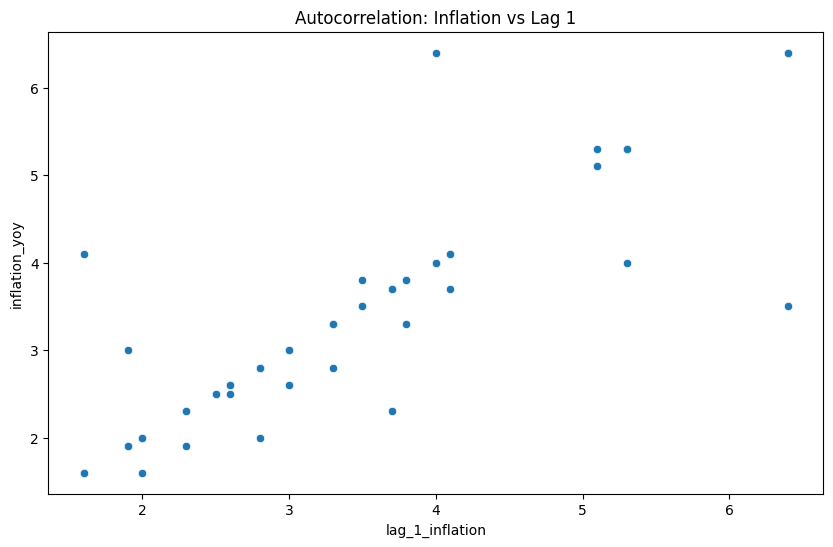

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

if not df_feat.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_feat, x='lag_1_inflation', y='inflation_yoy')
    plt.title("Autocorrelation: Inflation vs Lag 1")
    plt.show()
else:
    print("⚠️ Skipping: No feature data to visualize.")